# 01. Препроцессинг данных бурения

**Вход:** `cleared.csv` (df1), `cleared2.csv` (df2)  
**Выход:** `preprocessed.csv` (объединённый, очищенный)

**Что делаем:**
1. Загружаем оба датасета
2. Исправляем ошибку d_depth в df2
3. Применяем одинаковые фильтры
4. Объединяем
5. Создаём log₁₀(EI)

**Ключевые переменные:**

| Обозначение | Столбец | Роль |
|---|---|---|
| P_ос | `pressure_axis` | Вход (управляемый) — осевое давление |
| P_вр | `pressure_rotation` | Вход (управляемый) — давление вращения |
| E | `EI` → `log_EI` | Среда — энергоёмкость породы (для кластеризации) |
| v | `speed` | Выход (цель оптимизации) — скорость проходки |
| n | `rotation` | Выход — обороты рабочего органа |

**Важно:** EI = (P_ос × P_вр × n) / v — вычисляется из параметров бурения.  
Используем **только для кластеризации**, **не как фичу в модели** (data leakage).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 11

## Настраиваемые параметры

In [ ]:
MIN_WELL_RECORDS = 50
D_DEPTH_UPPER    = 0.5
ROTATION_LOWER   = 50
OUTPUT_FILE      = 'preprocessed.csv'

## 1. Загрузка df1

In [ ]:
df1 = pd.read_csv('cleared.csv', index_col = 0)
print(f'df1: {len(df1)} строк, {df1["well_id"].nunique()} скважин')
print(f'Столбцы: {list(df1.columns)}')
df1.head()

df1: 165966 строк, 866 скважин
Столбцы: ['time', 'processing_time', 'depth', 'course', 'rotation', 'pressure_air', 'pressure_axis', 'pressure_rotation', 'well_id', 'd_depth', 'd_time', 'speed', 'n/p', 'EI']


,time,processing_time,depth,course,rotation,pressure_air,pressure_axis,pressure_rotation,well_id,d_depth,d_time,speed,n/p,EI
0,2025-10-07 22:18:02,2025-10-07 22:18:09.425,4.5753,208,107.010,502,9610,9741,25512,0.4545,NaN,NaN,0.011135,6.580100e+04
1,2025-10-07 22:18:08,2025-10-07 22:18:14.495,4.6965,256,104.892,497,12781,13144,25512,0.1212,6.0,0.02020,0.008207,8.723352e+11
2,2025-10-07 22:18:13,2025-10-07 22:18:19.239,4.8783,359,101.430,501,18971,18936,25512,0.1818,5.0,0.03636,0.005347,1.002123e+12
3,2025-10-07 22:18:18,2025-10-07 22:18:24.208,5.0298,170,101.430,544,20153,18184,25512,0.1515,5.0,0.03030,0.005033,1.226741e+12
4,2025-10-07 22:18:23,2025-10-07 22:18:29.385,5.1813,218,102.714,559,20162,17445,25512,0.1515,5.0,0.03030,0.005094,1.192317e+12


## 2. Загрузка и исправление df2

**Критическая ошибка в df2:** `d_depth == depth` (полная глубина вместо дельты).  
Из-за этого `speed` и `EI` посчитаны неверно. Пересчитываем.

In [ ]:
df2 = pd.read_csv('cleared2.csv')
print(f'df2: {len(df2)} строк, {df2["well_id"].nunique()} скважин')

print(f'\n d_depth == depth: {(df2["d_depth"] == df2["depth"]).all()}')


df2: 272961 строк, 1246 скважин

 d_depth == depth: True


In [ ]:
df2 = df2.sort_values(['well_id', 'time']).reset_index(drop=True)

df2['d_depth'] = df2.groupby('well_id')['depth'].diff()
df2 = df2.dropna(subset=['d_depth']).copy()
df2 = df2[df2['d_depth'] > 0].copy()
df2['speed'] = df2['d_depth'] / df2['d_time']
df2['EI'] = (df2['pressure_axis'] * df2['pressure_rotation'] * df2['rotation']) / df2['speed']


## 3. Фильтрация 

In [ ]:
def preprocess(df, name):
    print(f'\n{name}: {len(df)} строк, {df["well_id"].nunique()} скважин')
    
    df = df.dropna(subset=['speed', 'EI']).copy()
    df = df[(df['speed'] > 0) & np.isfinite(df['EI']) & (df['EI'] > 0)].copy()
    print(f'  NaN/inf: {len(df)}')
    
    wc = df.groupby('well_id').size().reset_index(name='count')
    df = df[df['well_id'].isin(wc[wc['count'] >= MIN_WELL_RECORDS]['well_id'])].copy()
    print(f'  Скважины ≥ {MIN_WELL_RECORDS}: {len(df)} ({df["well_id"].nunique()} скважин)')
    
    df = df[df['d_depth'] <= D_DEPTH_UPPER].copy()
    print(f'  d_depth ≤ {D_DEPTH_UPPER}: {len(df)}')
    
    df = df[df['rotation'] >= ROTATION_LOWER].copy()
    print(f'  rotation ≥ {ROTATION_LOWER}: {len(df)}')
    
    df['log_EI'] = np.log10(df['EI'])
    return df

df1 = preprocess(df1, 'df1')
df2 = preprocess(df2, 'df2')


df1: 165966 строк, 866 скважин
  NaN/inf: 165552
  Скважины ≥ 50: 163503 (684 скважин)
  d_depth ≤ 0.5: 162433
  rotation ≥ 50: 161290

df2: 271544 строк, 1206 скважин
  NaN/inf: 271528
  Скважины ≥ 50: 269730 (1052 скважин)
  d_depth ≤ 0.5: 267812
  rotation ≥ 50: 265910


## 4. Объединение

In [ ]:
df1['source'] = 'df1'
df2['source'] = 'df2'

common_cols = [c for c in df1.columns if c in df2.columns]
df = pd.concat([df1[common_cols], df2[common_cols]], ignore_index=True)

print(f'\n Объединённый датасет: {len(df)} строк, {df["well_id"].nunique()} скважин')


 Объединённый датасет: 427200 строк, 1735 скважин


## 5. Сравнение распределений df1 vs df2

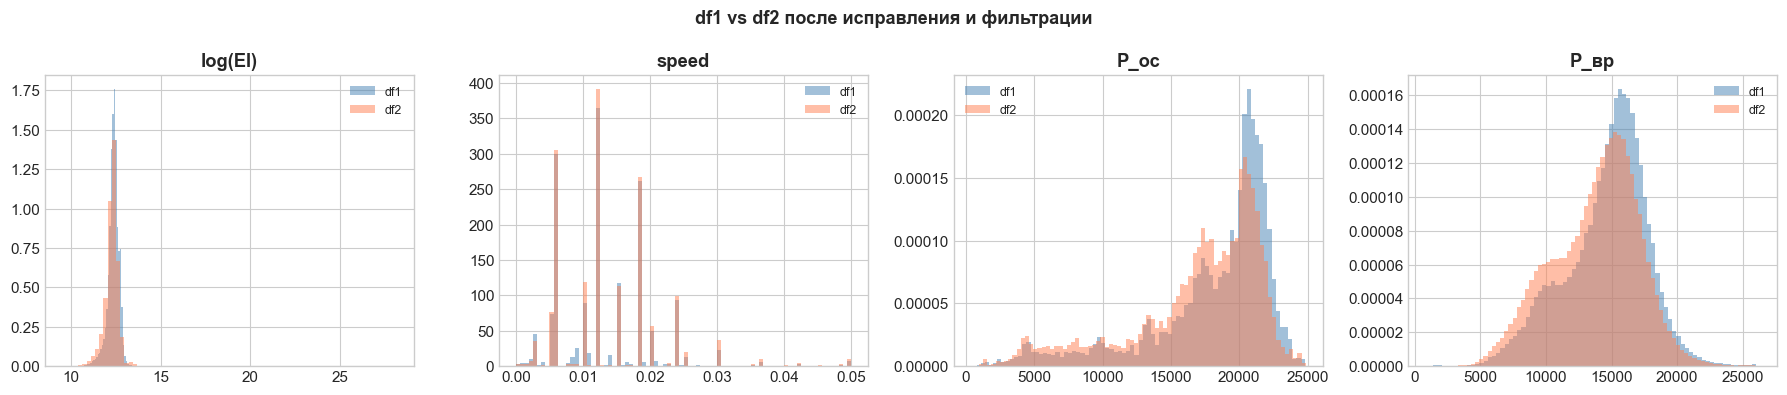

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col, title, xlim in zip(axes,
    ['log_EI', 'speed', 'pressure_axis', 'pressure_rotation'],
    ['log(EI)', 'speed', 'P_ос', 'P_вр'],
    [None, (0, 0.05), None, None]):
    d1, d2 = df[df['source']=='df1'][col], df[df['source']=='df2'][col]
    if xlim: d1, d2 = d1.clip(*xlim), d2.clip(*xlim)
    ax.hist(d1, bins=80, alpha=0.5, density=True, label='df1', color='steelblue')
    ax.hist(d2, bins=80, alpha=0.5, density=True, label='df2', color='coral')
    ax.set_title(title, fontweight='bold'); ax.legend(fontsize=9)
plt.suptitle('df1 и df2 после исправления и фильтрации', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Итоговая сводка

427200 строк, 1735 скважин, пропуски: 0

 Диапазоны:
  pressure_axis         : [317.0000 — 24872.0000], median=18794.0000
  pressure_rotation     : [784.0000 — 26318.0000], median=14608.0000
  rotation              : [50.0100 — 917.7000], median=103.2600
  speed                 : [0.0000 — 0.3333], median=0.0121
  log_EI                : [9.4748 — 28.1841], median=12.3480
  depth                 : [-1.1211 — 84.3552], median=9.6657


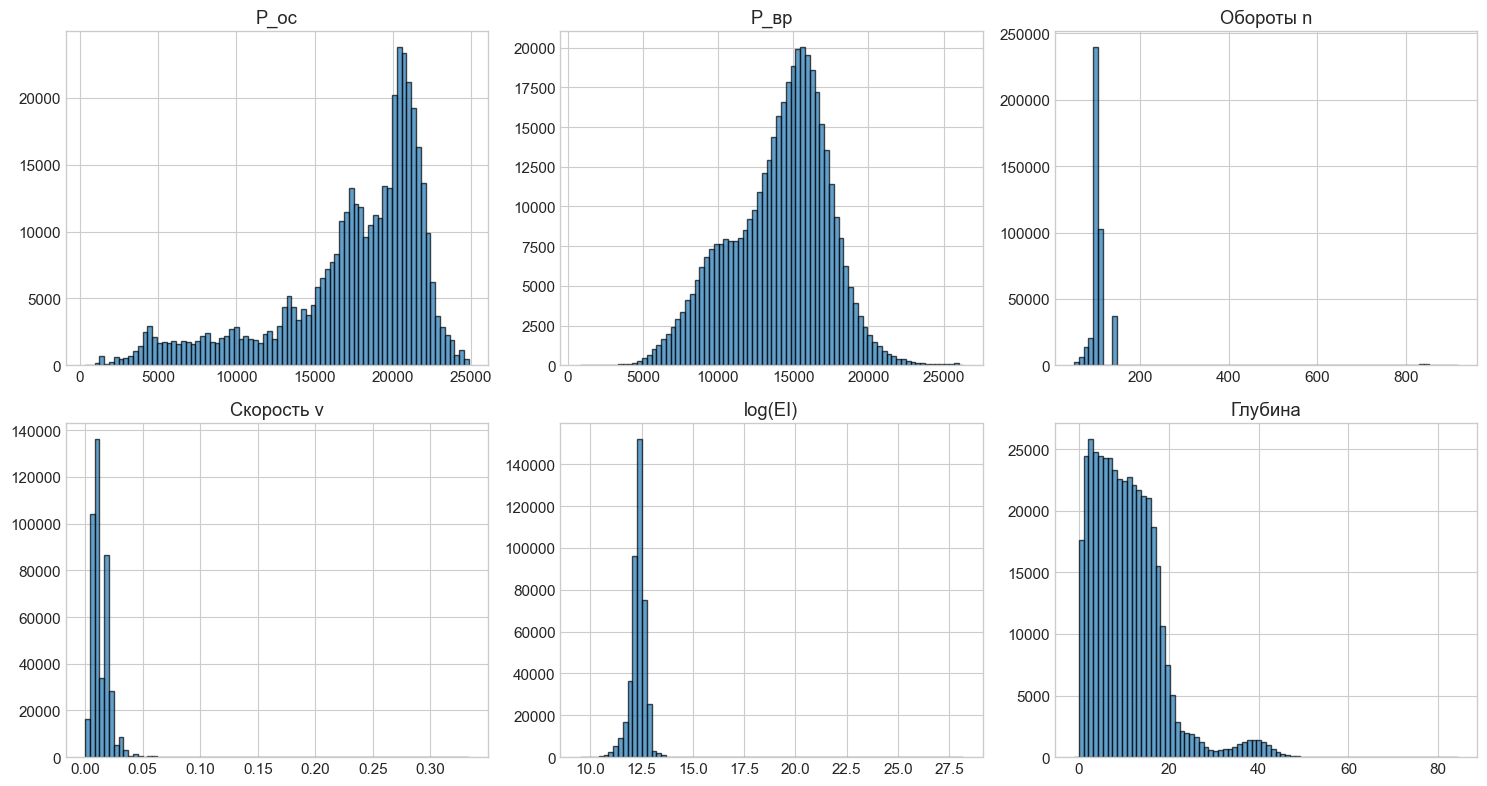

In [ ]:
print(f'{len(df)} строк, {df["well_id"].nunique()} скважин, пропуски: {df.isnull().sum().sum()}')
print(f'\n Диапазоны:')
for col in ['pressure_axis', 'pressure_rotation', 'rotation', 'speed', 'log_EI', 'depth']:
    s = df[col]
    print(f'  {col:22s}: [{s.min():.4f} — {s.max():.4f}], median={s.median():.4f}')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col, title in zip(axes.flat, ['pressure_axis', 'pressure_rotation', 'rotation', 'speed', 'log_EI', 'depth'],
    ['P_ос', 'P_вр', 'Обороты n', 'Скорость v', 'log(EI)', 'Глубина']):
    ax.hist(df[col], bins=80, edgecolor='black', alpha=0.7)
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 7. Сохранение

In [ ]:
df.to_csv(OUTPUT_FILE, index=False)
print(f'{len(df)} строк, {df["well_id"].nunique()}')

427200 строк, 1735
